In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("ForeignGifts_edu.csv")

**Summary**:
I propose schools should receive foreign funding based on their on-campus student populations. Below I compared UVA to other schools with a similar reputable status, UVA received less foreign funding than Duke, Berkeley and Texas in proportion to total student population. 

In [ ]:
#Student populations for each school came from each university's official website. The populations is the total on-campus student population Fall 2025 semester.
# UVA: https://admission.virginia.edu/admission/statistics
# Duke: https://facts.duke.edu/
# Texas at Austin: https://www.utexas.edu/about/facts-and-figures
# UC Berkeley:  https://opa.berkeley.edu/campus-data/uc-berkeley-quick-facts
schools = ['University of Virginia', 'Duke University', 'University of Texas at Austin', 'University of California, Berkeley']

df_schools = df[df['Institution Name'].isin(schools)]
totals = df_schools.groupby('Institution Name')['Foreign Gift Amount'].sum().reset_index()
totals['student_population'] = [17325, 46151, 55000, 26685]
totals['Amount of funding per student'] = totals['Foreign Gift Amount'] / totals['student_population']
totals

,Institution Name,Foreign Gift Amount,student_population,Amount of funding per student
0,Duke University,343699498,17325,19838.354863
1,"University of California, Berkeley",294479904,46151,6380.791402
2,University of Texas at Austin,85858408,55000,1561.061964
3,University of Virginia,22189238,26685,831.524752


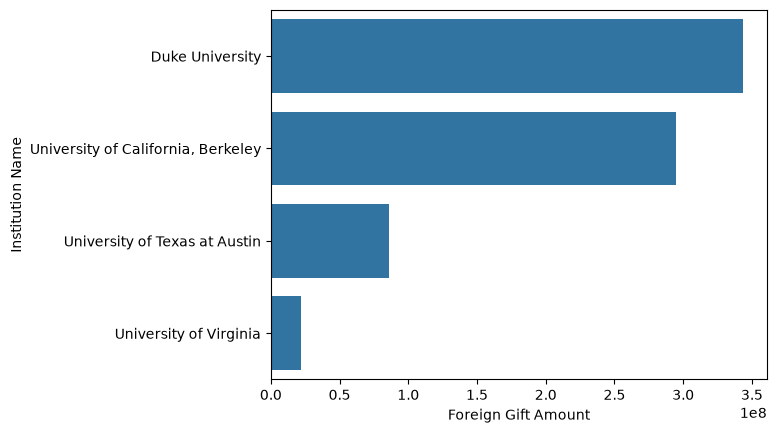

In [ ]:
#Graph to compare total recieved foreign gifts
sns.barplot(
    data=totals,
    y='Institution Name',
    x='Foreign Gift Amount',
    orient = "horizontal"
)
plt.show()

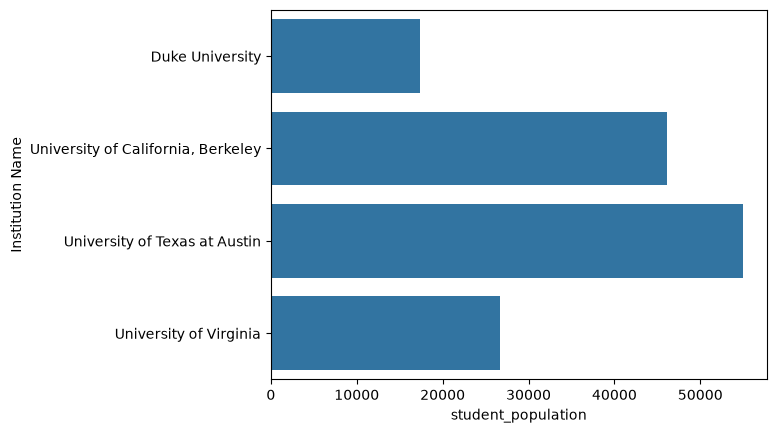

In [ ]:
#Graphing student populations for each school. 
sns.barplot(
    data=totals,
    y='Institution Name',
    x='student_population',
    orient = "horizontal"
)
plt.show()

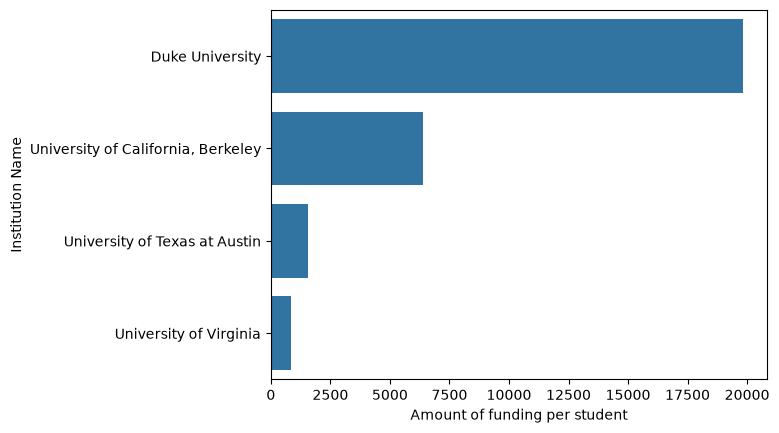

In [ ]:
#Amount of funding per student for each school
sns.barplot(
    data=totals,
    y='Institution Name',
    x='Amount of funding per student',
    orient = "horizontal"
)
plt.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

#Showing who donates to each of these universities.
giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'

flows = (
    df_schools.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)
fig.update_layout(height=1000)
fig.show()